In [4]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

In [8]:
# Load dataset
df = pd.read_csv("Country-data.csv")

# Exploratory Data Analysis

In [9]:
# Understand dataset structure
print(df.shape)
print(df.info())
print(df.describe().T)

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None
            count          mean           std       min       25%      50%  \
child_mort  167.0     38.270060     40.328931    2.6000     8.250    19.30   
exports     167.0     41.108976     27.412010    0.1090    23.800    35.00   
health      167.0      6.815689      2.746837    1.8100     4.920     6.32   
imports     1

In [10]:
# Check data quality
print(df.isnull().sum())
print(df.duplicated().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
0


In [11]:
# Detect potential outliers using IQR
numeric_cols = df.drop("country", axis=1)

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)

IQR = Q3 - Q1

outliers = (
    ((numeric_cols < (Q1 - 1.5 * IQR)) |
     (numeric_cols > (Q3 + 1.5 * IQR)))
).sum()

print(outliers)

child_mort     4
exports        5
health         2
imports        4
income         8
inflation      5
life_expec     3
total_fer      1
gdpp          25
dtype: int64


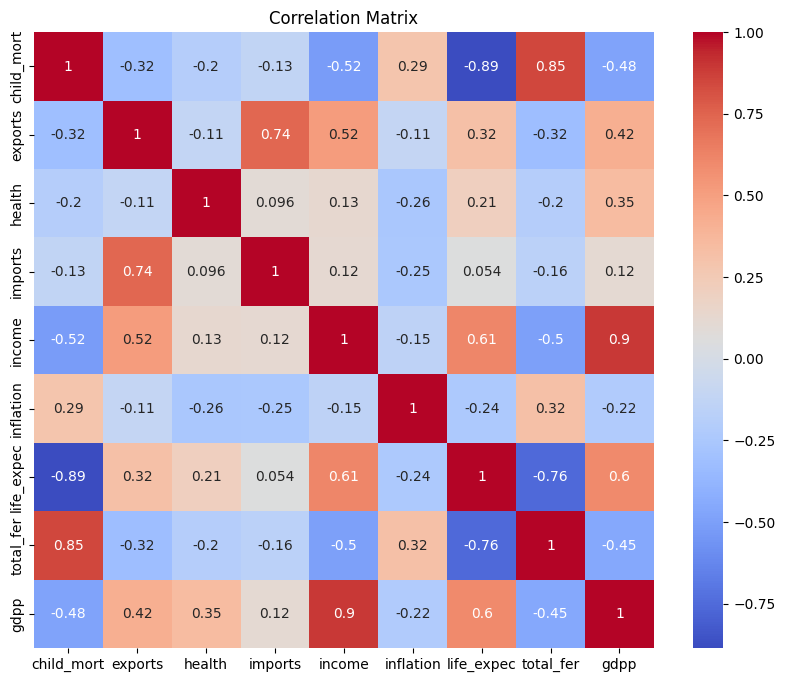

In [12]:
# Analyze feature relationships
corr = df.drop("country", axis=1).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [13]:
# View countries with highest risk indicators
print(df.nlargest(10, "child_mort")[["country","child_mort"]])

                      country  child_mort
66                      Haiti       208.0
132              Sierra Leone       160.0
32                       Chad       150.0
31   Central African Republic       149.0
97                       Mali       137.0
113                   Nigeria       130.0
112                     Niger       123.0
3                      Angola       119.0
25               Burkina Faso       116.0
37           Congo, Dem. Rep.       116.0


# Feature Engineering

In [14]:
# Create additional socio-economic indicators

df["trade_balance"] = (
    df["exports"] - df["imports"]
)

df["health_income_ratio"] = (
    df["health"] / df["income"]
)

df["mortality_fertility"] = (
    df["child_mort"] * df["total_fer"]
)

In [15]:
# Remove country names before modeling
country_names = df["country"]

X = df.drop("country", axis=1)

In [18]:
# Standardize features to avoid scale bias
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

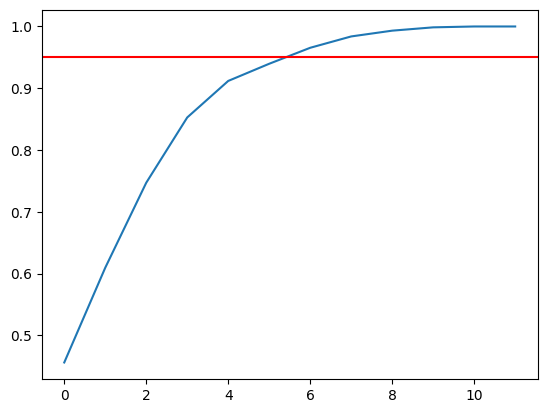

Components Retained: 7


In [19]:
# Reduce dimensionality while retaining information by PCA

pca = PCA()
pca.fit(X_scaled)

cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.plot(cum_var)
plt.axhline(0.95,color='red')
plt.show()

# Retain 95% variance
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print(
    "Components Retained:",
    pca.n_components_
)

# Elbow Method

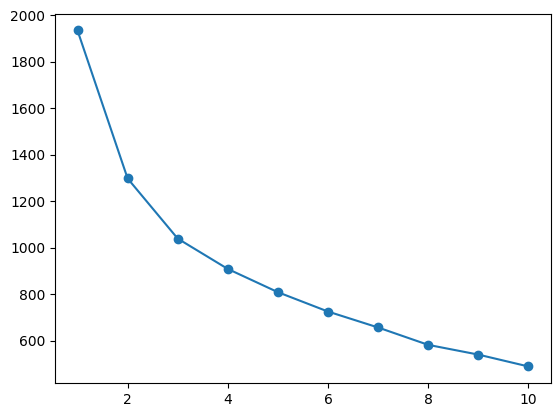

In [20]:
# Identify optimal number of clusters
wcss = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km.fit(X_pca)

    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.show()

# Silhouette Analysis

In [21]:
# Validate cluster separation quality

scores = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_pca)

    scores.append(
        silhouette_score(
            X_pca,
            labels
        )
    )

print(scores)

[np.float64(0.36240699833793794), np.float64(0.2939464193574782), np.float64(0.29043230622465205), np.float64(0.290993257016598), np.float64(0.23945281559465506), np.float64(0.2415650180009339), np.float64(0.24968384523999143), np.float64(0.2411761657342154), np.float64(0.25481801383379676)]


# K-Means Clustering

In [22]:
# Segment countries into development groups

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50
)

df["Cluster"] = kmeans.fit_predict(X_pca)

# Profile clusters for interpretation
cluster_profile = df.groupby(
    "Cluster"
).mean(
    numeric_only=True
)

print(cluster_profile)

         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0         25.187912  40.465813  6.221429  47.004021  11690.989011   8.004462   
1        100.187179  25.705385  6.467179  42.523077   2814.948718  11.779359   
2          5.181081  58.927027  8.644595  51.213514  45662.162162   3.020676   

         life_expec  total_fer          gdpp  trade_balance  \
Cluster                                                       
0         71.781319   2.433077   6184.857143      -6.538208   
1         58.717949   5.253846   1361.333333     -16.817692   
2         80.018919   1.783784  41867.567568       7.713514   

         health_income_ratio  mortality_fertility  
Cluster                                            
0                   0.000816            70.201352  
1                   0.004554           530.602308  
2                   0.000224             9.673324  


# Classification

In [24]:
# Use cluster labels as target classes
X_class = df.drop(
    ["country","Cluster"],
    axis=1
)

y = df["Cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest

In [25]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

print(
    accuracy_score(
        y_test,
        rf_pred
    )
)

1.0


In [26]:
# Identify most influential features

rf_importance = pd.DataFrame({

    "Feature":X_class.columns,
    "Importance":rf.feature_importances_

}).sort_values(
    "Importance",
    ascending=False
)

print(rf_importance.head())

                Feature  Importance
4                income    0.188188
0            child_mort    0.178777
8                  gdpp    0.167079
11  mortality_fertility    0.159922
6            life_expec    0.100140


# XGBoost

In [27]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

print(
    accuracy_score(
        y_test,
        xgb_pred
    )
)

1.0


In [28]:
# Feature importance from XGBoost

xgb_importance = pd.DataFrame({

    "Feature":X_class.columns,
    "Importance":xgb.feature_importances_

}).sort_values(
    "Importance",
    ascending=False
)

print(xgb_importance.head())

                Feature  Importance
8                  gdpp    0.291516
11  mortality_fertility    0.260652
4                income    0.188331
0            child_mort    0.074275
6            life_expec    0.063823


# DBSCAN

In [29]:
# Detect outlier countries and validate clusters
dbscan = DBSCAN(
    eps=1.3,
    min_samples=5
)

df["DBSCAN"] = dbscan.fit_predict(
    X_pca
)

print(
    df["DBSCAN"].value_counts()
)

DBSCAN
 0    106
-1     54
 1      7
Name: count, dtype: int64


# Need Index

In [30]:
# Build aid-priority scoring framework
need_cols = [

    "child_mort",
    "income",
    "gdpp",
    "life_expec",
    "total_fer"

]

scaled = MinMaxScaler().fit_transform(
    df[need_cols]
)

scaled = pd.DataFrame(
    scaled,
    columns=need_cols
)

df["Need_Index"] = (

      0.30 * scaled["child_mort"]

    - 0.25 * scaled["income"]

    - 0.20 * scaled["gdpp"]

    - 0.15 * scaled["life_expec"]

    + 0.10 * scaled["total_fer"]

)

In [31]:
# Rank countries by aid requirement
priority = df.sort_values(
    "Need_Index",
    ascending=False
)

print(
    priority[
        [
            "country",
            "Need_Index"
        ]
    ].head(20)
)

                      country  Need_Index
66                      Haiti    0.331771
31   Central African Republic    0.231331
32                       Chad    0.224976
132              Sierra Leone    0.224473
97                       Mali    0.196963
112                     Niger    0.196223
37           Congo, Dem. Rep.    0.175299
113                   Nigeria    0.162894
25               Burkina Faso    0.161438
64              Guinea-Bissau    0.152522
3                      Angola    0.149260
106                Mozambique    0.146026
40              Cote d'Ivoire    0.145641
63                     Guinea    0.142901
26                    Burundi    0.137460
28                   Cameroon    0.135666
17                      Benin    0.133419
94                     Malawi    0.130587
87                    Lesotho    0.127777
0                 Afghanistan    0.127677


# Export final results

In [32]:
# Export final results
df.to_csv(
    "Country_Output.csv",
    index=False
)